# Module 1 — Exercises (Student Worksheet)
### DeepSets, PFN & EFN · *Sets, Graphs & Symmetry for High-Energy Physics* (TIFR ML School 2026)

This worksheet covers **all five exercises** at the end of
`Module1_DeepSets_PFN_EFN.ipynb`. It is **self-contained**: the *Setup* section below re-imports the
libraries, reloads the JetClass data, and re-defines the DeepSets/PFN/EFN building blocks from the
module, so you can run this notebook on its own.

| # | Exercise | Idea it drives home |
|---|----------|---------------------|
| 1 | **Pooling matters** | `mean` forgets multiplicity; the Deep Sets theorem is stated with `sum` for a reason |
| 2 | **Jet-mass regression** | DeepSets is not just a classifier — the same pool regresses a physical observable |
| 3 | **Multiclass** | one head, four jet types; the confusion matrix is *physics* |
| 4 | **IRC-safety in practice** | the EFN is flat *by construction*; how far does the trained PFN actually drift? |
| 5 | **Attention pooling** | a learned, permutation-invariant pool = a one-line Set-Transformer teaser for Module 3 |

Each section restates the problem, explains the approach and the physics/ML behind it, gives runnable
code, and closes with a short discussion of what the numbers mean.

> **Speed knobs.** `N_PER_GRP`, `MAX_PART` and the per-exercise `epochs` trade accuracy for runtime.
> The defaults train in a few minutes on a laptop (CPU / Apple-MPS). Raise them to sharpen every effect.

> **How to use this worksheet.** Run the **Setup** section as-is (it loads the data and provides the models/helpers from the module). Then complete each exercise where you see `# TODO` and `raise NotImplementedError`. Read the **prompt** above each exercise — it sketches the approach. Check your work against the matching `*_Exercises_Solutions.ipynb`.

## Setup — imports, data, and the Module-1 building blocks

Nothing new here: this is the machinery from Module 1, gathered in one place. We load a **balanced,
four-group** JetClass sample (QCD, Higgs, W/Z, top) *once* — that single sample feeds the multiclass
exercise (§3) and the mass-regression exercise (§2), and we carve the **top-vs-QCD** binary subset out
of it for the IRC (§4) and attention-pooling (§5) exercises.

In [3]:
import os, re
from datetime import datetime
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

# Save figures under the notebook's Exercises folder to match the project layout.
repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if os.path.isdir(os.path.join(repo_root, "MainSchool", "Exercises")):
    FIG_DIR = os.path.abspath(os.path.join(repo_root, "MainSchool", "Exercises", "figures"))
elif os.path.isdir(os.path.join(os.getcwd(), "Exercises")):
    FIG_DIR = os.path.abspath(os.path.join(os.getcwd(), "Exercises", "figures"))
elif os.path.basename(os.getcwd()) == "Exercises":
    FIG_DIR = os.path.abspath(os.path.join(os.getcwd(), "figures"))
else:
    FIG_DIR = os.path.abspath(os.path.join(os.getcwd(), "figures"))
os.makedirs(FIG_DIR, exist_ok=True)

def save_figure(fig=None, name="plot", folder=FIG_DIR, dpi=180):
    """Save a matplotlib figure to a timestamped filename in a project-local folder."""
    if fig is None:
        fig = plt.gcf()
    os.makedirs(folder, exist_ok=True)
    stem = re.sub(r"[^A-Za-z0-9_.-]+", "_", name).strip("_.") or "plot"
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    path = os.path.join(folder, f"{stem}_{stamp}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path

torch.manual_seed(0); np.random.seed(0)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)


Using device: mps


In [4]:
# ========================================================================================
# MODULE-1 BUILDING BLOCKS
# ========================================================================================

# ----------------------------------------------------------------------------------------
# 1. THE MULTI-LAYER PERCEPTRON (MLP) FACTORY
# ----------------------------------------------------------------------------------------
def make_mlp(in_dim, hidden, out_dim, act=nn.ReLU):
    """
    Constructs a sequential neural network consisting of fully connected (Linear) layers.
    Mathematically, it builds a mapping: $\mathbb{R}^{in} \rightarrow \mathbb{R}^{out}$
    """
    # Unpack the dimensions into a single list.
    dims = [in_dim, *hidden]; layers = []

    # Loop through pairs of dimensions, creating the matrix multiplications ($W x + b$)
    # followed by the non-linear activation function (ReLU).
    for a, b in zip(dims[:-1], dims[1:]):
        layers += [nn.Linear(a, b), act()]

    # Append the final unactivated layer to output raw real numbers (logits).
    layers += [nn.Linear(dims[-1], out_dim)]

    # Bundle into a single callable PyTorch module.
    return nn.Sequential(*layers)


# ----------------------------------------------------------------------------------------
# 2. INVARIANT POOLING OPERATORS
# ----------------------------------------------------------------------------------------
def masked_sum(x, mask):    # x:(B,N,C) mask:(B,N)
    """
    Computes the permutation-invariant sum of particle features, completely erasing padded zeros.
    Math: $\sum_{i=1}^N (x_i \cdot m_i)$
    """
    # mask.unsqueeze(-1) aligns the 2D mask with the 3D feature tensor.
    # The multiplication physically zeroes out fake particles before the dimension collapse (.sum).
    return (x * mask.unsqueeze(-1)).sum(dim=1)

def masked_mean(x, mask):
    """
    Computes the mathematical average of valid particles only.
    Math: $\frac{\sum_{i=1}^N (x_i \cdot m_i)}{\sum_{i=1}^N m_i}$
    """
    # Divides the safe sum by the actual count of true particles (mask.sum).
    # .clamp(min=1.0) prevents a catastrophic division by zero if the mask is entirely empty.
    return masked_sum(x, mask) / mask.sum(dim=1, keepdim=True).clamp(min=1.0)


# ----------------------------------------------------------------------------------------
# 3. DEEP SETS CLASSIFIER (PARTICLE FLOW NETWORK)
# ----------------------------------------------------------------------------------------
class DeepSetsClassifier(nn.Module):
    """
    Canonical Deep Sets / PFN:  out = F( pool_i Phi(x_i) ).
    (n_classes=1 => regression head.)

    This implements the universal approximation theorem for sets:
    $f(X) = \rho\left(\sum_{x_i \in X} \phi(x_i)\right)$
    """
    def __init__(self, in_features, phi_hidden=(64, 128, 128), latent=128,
                 f_hidden=(128, 64), n_classes=2, pool="sum"):
        super().__init__()
        self.pool = pool

        # $\phi$: The independent, per-particle feature extractor mapping into latent space.
        self.phi  = make_mlp(in_features, phi_hidden, latent)

        # $F$ (or $\rho$): The global decoder mapping the pooled set to class logits.
        self.f    = make_mlp(latent, f_hidden, n_classes)

    def forward(self, x, mask):
        # 1. Apply $\phi$ to every particle independently.
        h = self.phi(x)
        # 2. Collapse the particle dimension using a symmetric, permutation-invariant operator.
        z = masked_sum(h, mask) if self.pool == "sum" else masked_mean(h, mask)
        # 3. Decode the global representation.
        return self.f(z)


# ----------------------------------------------------------------------------------------
# 4. ENERGY FLOW NETWORK (EFN)
# ----------------------------------------------------------------------------------------
class EFN(nn.Module):
    """
    Energy Flow Network (IRC-safe):  F( sum_i z_i * Phi(angles_i) ).

    This imposes strict physics priors (Infrared and Collinear safety) directly onto the architecture.
    Math: $f(X) = F\left(\sum_{i=1}^N z_i \phi(\hat{p}_i)\right)$
    where $z_i$ is the energy fraction and $\hat{p}_i$ contains only the geometric angles.
    """
    def __init__(self, n_angle=2, phi_hidden=(64, 128, 128), latent=128,
                 f_hidden=(128, 64), n_classes=2):
        super().__init__()

        # $\phi$: Extracts latent geometry representations STRICTLY from angles, not energy.
        self.phi = make_mlp(n_angle, phi_hidden, latent)

        # $F$: Decodes the energy-weighted geometry.
        self.f   = make_mlp(latent, f_hidden, n_classes)

    def forward(self, angles, z, mask):
        # 1. Embed the pure geometry.
        h = self.phi(angles)

        # 2. Apply the valid mask directly to the energy fractions ($z_i$).
        w = (z * mask).unsqueeze(-1)

        # 3. Multiply the latent geometry by the particle's energy fraction and sum it up.
        # This guarantees that particles with 0 energy contribute 0 (Infrared safety),
        # and collinear splits sum perfectly together (Collinear safety).
        return self.f((w * h).sum(dim=1))


# ----------------------------------------------------------------------------------------
# 5. PHYSICS EVALUATION METRIC
# ----------------------------------------------------------------------------------------
def background_rejection(y, p, target_eff=0.5):
    """
    Calculates Background Rejection: The mathematical inverse of the False Positive Rate,
    evaluated at a strict, fixed True Positive Rate (Signal Efficiency).
    Math: $1 / \epsilon_B$ where $\epsilon_S = target\_eff$
    """
    # Compute the ROC curve coordinates (False Positive Rate, True Positive Rate).
    fpr, tpr, _ = roc_curve(y, p)

    # np.interp estimates the exact False Positive Rate ($\epsilon_B$) when
    # the True Positive Rate ($\epsilon_S$) is exactly 0.5.
    # We return the inverse (1.0 / $\epsilon_B$), clamping the denominator to prevent crashes.
    return 1.0 / max(np.interp(target_eff, tpr, fpr), 1e-12)

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:89: SyntaxWarning: invalid escape sequence '\l'
<>:122: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:89: SyntaxWarning: invalid escape sequence '\l'
<>:122: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0s/9r0n20j90w36bt6vmbn27lp40000gn/T/ipykernel_41812/2666784998.py:11: SyntaxWarning: invalid escape sequence '\m'
  Mathematically, it builds a mapping: $\mathbb{R}^{in} \rightarrow \mathbb{R}^{out}$
/var/folders/0s/9r0n20j90w36bt6vmbn27lp40000gn/T/ipykernel_41812/2666784998.py:34: SyntaxWarning: invalid escape sequence '\s'
  Math: $\sum_{i=1}^N (x_i \cdot m_i)$
/var/fo

In [5]:
# --- Locate + load the JetClass example file --------------------------------------------
import uproot, awkward as ak

CANDIDATE_PATHS = [
    "../data/JetClass_example_100k.root",
    "/Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root",
    "./JetClass_example_100k.root",
]
root_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if root_path is None:
    raise FileNotFoundError("JetClass_example_100k.root not found; searched:\n  " + "\n  ".join(CANDIDATE_PATHS))
print("Using:", root_path)

MAX_PART   = 128     # pad / truncate every jet to this many particles
N_PER_GRP  = 4000    # jets per GROUP (QCD, H, V, top); raise for accuracy, lower for speed

tree = uproot.open(root_path)["tree"]
LABELS10 = ["label_QCD","label_Hbb","label_Hcc","label_Hgg","label_H4q","label_Hqql",
            "label_Zqq","label_Wqq","label_Tbqq","label_Tbl"]
br = tree.arrays(["part_px","part_py","part_pz","part_energy","part_deta","part_dphi",
                  "jet_sdmass","jet_pt"] + LABELS10)

Using: ../data/JetClass_example_100k.root


In [6]:
# --- Build a balanced 4-group sample: 0=QCD, 1=Higgs, 2=W/Z (V), 3=top -------------------
onehot = np.stack([ak.to_numpy(br[k]).astype(bool) for k in LABELS10], axis=1)  # (Njet,10)
GROUPS = {
    0: ["label_QCD"],
    1: ["label_Hbb","label_Hcc","label_Hgg","label_H4q","label_Hqql"],
    2: ["label_Zqq","label_Wqq"],
    3: ["label_Tbqq","label_Tbl"],
}
GROUP_NAMES = ["QCD", "H", "W/Z", "top"]
col = {k: i for i, k in enumerate(LABELS10)}

rng = np.random.default_rng(0)
sel, y4 = [], []
for g, keys in GROUPS.items():
    in_g = np.any(onehot[:, [col[k] for k in keys]], axis=1)
    idx = np.where(in_g)[0]
    idx = rng.permutation(idx)[:N_PER_GRP]
    sel.append(idx); y4.append(np.full(len(idx), g))
    print(f"group {g} ({GROUP_NAMES[g]:>4}): {len(idx)} jets")
sel = np.concatenate(sel); y4 = np.concatenate(y4).astype(np.int64)

# per-particle kinematics for the selected jets (still jagged)
px, py, pz, e = br["part_px"][sel], br["part_py"][sel], br["part_pz"][sel], br["part_energy"][sel]
deta, dphi    = br["part_deta"][sel], br["part_dphi"][sel]
sdmass = ak.to_numpy(br["jet_sdmass"][sel]).astype(np.float32)   # target for the regression exercise

group 0 ( QCD): 4000 jets
group 1 (   H): 4000 jets
group 2 ( W/Z): 4000 jets
group 3 ( top): 4000 jets


In [7]:
# ========================================================================================
# HIGH-ENERGY PHYSICS: FEATURE ENGINEERING & KINEMATICS
# ========================================================================================

# Calculate Transverse Momentum ($p_T$): The momentum perpendicular to the beam axis.
# Math: $p_T = \sqrt{p_x^2 + p_y^2}$
pt = np.sqrt(px**2 + py**2)

# Calculate $\Delta R$: The standard spatial distance metric in collider physics,
# combining pseudorapidity ($\eta$) and azimuthal angle ($\phi$).
# Math: $\Delta R = \sqrt{\Delta\eta^2 + \Delta\phi^2}$
dR = np.sqrt(deta**2 + dphi**2)

# Calculate the total transverse momentum and total energy for each individual jet.
# 'ak' (Awkward Array) handles jagged arrays where each row (jet) has a different number of items (particles).
# axis=1 tells it to sum across the particles, collapsing them into a single scalar value per jet.
sumpt = ak.sum(pt, axis=1)
sume = ak.sum(e, axis=1)

# Define the 7 core features for the Particle Flow Network (PFN).
FEATURE_NAMES = ["deta","dphi","log_pt","log_e","log_pt_rel","log_e_rel","dR"]

# Construct the feature arrays.
# We apply natural logarithms ($\log$) to momentum and energy because their distributions
# fall off exponentially; taking the log makes the data distribution more normal (Gaussian),
# which helps the neural network converge faster.
# '+ 1e-8' is a tiny mathematical safety buffer to prevent $\log(0)$, which would yield
# negative infinity and instantly crash the model with NaN (Not a Number) errors.
# 'pt/sumpt' and 'e/sume' represent the relative fractions of the jet's total momentum/energy.
feat_list = [deta, dphi, np.log(pt+1e-8), np.log(e+1e-8),
             np.log(pt/sumpt+1e-8), np.log(e/sume+1e-8), dR]


# ========================================================================================
# JAGGED TO DENSE TENSOR CONVERSION
# ========================================================================================

def pad_feature(f):
    """
    Converts a jagged Awkward array into a perfectly rectangular standard NumPy matrix.
    Neural networks require fixed-size inputs, but jets have varying particle counts.
    """
    # 1. ak.pad_none(..., MAX_PART, clip=True): Enforces a strict particle limit.
    #    If a jet has fewer than MAX_PART, it adds 'None' (null) slots.
    #    If a jet has more than MAX_PART, clip=True truncates the excess particles.
    # 2. ak.fill_none(..., 0.0): Replaces all the null slots with actual 0.0 float values.
    # 3. ak.to_numpy(): Converts the underlying structure to a fast C-contiguous NumPy array.
    return ak.to_numpy(ak.fill_none(ak.pad_none(f, MAX_PART, clip=True), 0.0))

# Process all 7 features through the padding function.
# np.stack(..., axis=-1) aligns these 7 separate 2D matrices (Jets x Particles) and
# stacks them along a new 3rd dimension (the depth or feature axis).
# .astype(np.float32) forces 32-bit floats, which is the standard precision required by GPUs.
# Final shape of X: (N_jets, MAX_PART, 7)
X = np.stack([pad_feature(f) for f in feat_list], axis=-1).astype(np.float32)


# ========================================================================================
# MASKING & ENERGY FLOW NETWORK (EFN) PREPARATION
# ========================================================================================

# Count the actual number of valid particles in each jet (before padding),
# capping the maximum reported count at MAX_PART.
nparts = np.minimum(ak.to_numpy(ak.num(pt, axis=1)), MAX_PART)

# Create a boolean validity mask using NumPy broadcasting:
# np.arange(MAX_PART)[None, :] creates a row vector of indices: [0, 1, 2, ... MAX_PART-1]
# nparts[:, None] creates a column vector of true particle counts.
# The '<' operator compares them, yielding 1.0 (True) if the index represents a real particle,
# and 0.0 (False) if the index falls into the padded zone.
mask = (np.arange(MAX_PART)[None, :] < nparts[:, None]).astype(np.float32)

# EFNs require raw, un-normalized spatial geometry to maintain Infrared/Collinear safety.
# We pad and stack strictly the $\Delta\eta$ and $\Delta\phi$ spatial angles.
angles = np.stack([pad_feature(deta), pad_feature(dphi)], axis=-1).astype(np.float32)

# EFNs use the raw linear energy fraction ($z = p_T / \sum p_T$), rather than the logarithmic version.
# We calculate it, pad it, and cast it to float32.
zfrac = pad_feature(pt/sumpt).astype(np.float32)

# Print a final sanity check of the array dimensions before they get passed to PyTorch.
# (Note: 'sdmass' refers to the Soft Drop mass of the jet, a physics observable likely calculated earlier in the script).
print("X:", X.shape, " mask:", mask.shape, " angles:", angles.shape, " sdmass:", sdmass.shape)

X: (16000, 128, 7)  mask: (16000, 128)  angles: (16000, 128, 2)  sdmass: (16000,)


In [8]:
# ========================================================================================
# MEMORY-EFFICIENT TENSOR CONVERSION
# ========================================================================================

# torch.from_numpy takes our existing NumPy arrays and creates PyTorch tensors that point
# to the exact same physical memory addresses. This is a "zero-copy" operation, meaning
# we don't waste time or RAM duplicating the massive physics datasets.
Xt = torch.from_numpy(X)
Mt = torch.from_numpy(mask)
Y4 = torch.from_numpy(y4)  # Y4 contains 4 distinct classes of jets
AnglesT = torch.from_numpy(angles)
Zt = torch.from_numpy(zfrac)
SDt = torch.from_numpy(sdmass)  # Soft Drop mass (a physics observable)


# ========================================================================================
# SYNCHRONIZED DATASET SHUFFLING
# ========================================================================================

# Create a random number generator and permanently lock its starting seed to 0.
# This guarantees deterministic behavior: every time the script runs, the data is shuffled
# in the exact same "random" order, which is mandatory for reproducing scientific results.
g = torch.Generator().manual_seed(0)

# randperm creates a 1D tensor of integers from 0 to len(Y4)-1 in a completely scrambled order.
perm = torch.randperm(len(Y4), generator=g)

# By indexing every single tensor with the exact same 'perm' array, we shuffle the rows
# of all our datasets simultaneously. Jet #42's features, mask, mass, and label all move
# to their new location together, keeping the physics completely intact.
Xt, Mt, Y4, AnglesT, Zt, SDt = (
    Xt[perm],
    Mt[perm],
    Y4[perm],
    AnglesT[perm],
    Zt[perm],
    SDt[perm],
)


# ========================================================================================
# DATA SPLITTING (70% TRAIN / 15% VAL / 15% TEST)
# ========================================================================================

n = len(Y4)
# Calculate the exact integer cutoffs for the subsets.
# 70% of the data goes to training (updating network weights).
# 15% goes to validation (tuning hyperparameters without updating weights).
n_tr, n_va = int(0.70 * n), int(0.15 * n)

# We use standard Python 'slice' objects to store the index ranges cleanly.
# slice(start, stop) acts exactly like the colon operator in array[start:stop].
sl = {
    "train": slice(0, n_tr),
    "val": slice(n_tr, n_tr + n_va),
    "test": slice(n_tr + n_va, n),
}


# ========================================================================================
# Z-SCORE STANDARDIZATION (PREVENTING DATA LEAKAGE)
# ========================================================================================

# CRITICAL ML CONCEPT: Data Leakage.
# You must NEVER calculate statistical bounds using the Validation or Test sets. The model
# should act as if those datasets don't exist yet.

# 1. Xt[sl["train"]] grabs only the 70% of jets allocated for training.
# 2. Mt[sl["train"]].bool() grabs their corresponding masks, converted to True/False.
# 3. Passing the 2D boolean mask into the 3D tensor filters out all the padded zeros,
#    collapsing the tensor into a 2D matrix ('flat') of ONLY physically real particles.
flat = Xt[sl["train"]][Mt[sl["train"]].bool()]

# Calculate the mean ($\mu$) and standard deviation ($\sigma$) across axis 0 (the particle axis).
# This yields one mean and one standard deviation for each of the 7 physics features.
# .clamp(min=1e-6) prevents $\sigma$ from ever being exactly 0, preventing a fatal divide-by-zero.
feat_mean, feat_std = flat.mean(0), flat.std(0).clamp(min=1e-6)

# Apply standard Z-score normalization: $Z = \frac{X - \mu}{\sigma}$
# This centers all feature distributions around 0.0 with a standard deviation of 1.0,
# which drastically improves the stability and speed of neural network gradient descent.
Xt = (Xt - feat_mean) / feat_std

# NOTE: The mathematically padded 0.0s are now non-zero because of the subtraction.
# This is completely fine—our 'masked_sum' and 'w * h' functions in the network architectures
# will multiply these dummy slots by 0 (via the mask) before aggregating them, destroying the garbage data.

# Print a sanity check: extract the real training particles again. Their means should now hover right around 0.0.
print(
    "standardized train means ~0:",
    Xt[sl["train"]][Mt[sl["train"]].bool()].mean(0).numpy().round(2),
)


# ========================================================================================
# BINARY CLASSIFICATION PREP (SUBSET EXTRACTION)
# ========================================================================================

# The master dataset (Y4) has 4 classes. For specific later sections (§4 and §5),
# we only want to train a binary model to distinguish QCD background (Class 0) from Top quarks (Class 3).
# The bitwise OR (|) creates a boolean mask that is True ONLY if the jet is class 0 or class 3.
binmask = (Y4 == 0) | (Y4 == 3)

# We create a new target tensor 'Yb' (Y-binary).
# (Y4 == 3) evaluates to True for Top jets and False for QCD jets.
# .long() casts those booleans to 64-bit integers: 1 for Top (Signal), 0 for QCD (Background).
Yb = (Y4 == 3).long()

# Print the total number of jets that passed our binary filter mask.
print("binary top-vs-QCD jets:", int(binmask.sum().item()))


standardized train means ~0: [ 0.  0. -0. -0.  0.  0.  0.]
binary top-vs-QCD jets: 8000


In [9]:
# ========================================================================================
# CUSTOM DATASET & DATALOADER FACTORY
# ========================================================================================

# We define a flexible PyTorch Dataset that can handle any arbitrary number of input tensors.
# This is required because our different architectures take different inputs:
# - PFNs need: (Features, Masks, Labels)
# - EFNs need: (Angles, Energy_Fractions, Masks, Labels)
class TensorSet(Dataset):
    # Store the tuple of tensors passed during initialization.
    def __init__(self, tensors):
        self.tensors = tensors

    # Returns the total number of samples (e.g., total jets) by checking the length
    # of the very first tensor in the tuple.
    def __len__(self):
        return len(self.tensors[0])

    # When the DataLoader requests index 'i', this generator expression loops through
    # all tensors and extracts the i-th row from each, bundling them into a single tuple.
    def __getitem__(self, i):
        return tuple(t[i] for t in self.tensors)

# A helper function to instantly generate 'train', 'val', and 'test' DataLoaders in one line.
# 'tensors_by_split' is a dictionary like {"train": (X_train, Y_train), "val": (X_val, Y_val)}
def loaders_from(tensors_by_split, bs=256):
    return {
        # Create a DataLoader for each dataset split (k).
        # batch_size=bs serves the data in chunks (default 256).
        # shuffle=(k == "train") dynamically ensures only the training data gets randomized
        # (to prevent pattern memorization), while validation and testing remain deterministic.
        k: DataLoader(TensorSet(t), batch_size=bs, shuffle=(k == "train"))
        for k, t in tensors_by_split.items()
    }


# ========================================================================================
# UNIVERSAL TRAINING LOOP
# ========================================================================================

# This training function is "generic" because it takes a 'forward' function as an argument.
# Instead of hardcoding whether the model takes 3 inputs (PFN) or 4 inputs (EFN), we pass in
# a custom routing function that tells the loop exactly how to unpack the batch for that specific model.
def train_classifier(model, loaders, forward, epochs=8, lr=1e-3, n_out=2, quiet=False):
    """forward(model, batch)->(logits, y). Reports val AUC (binary) or accuracy (multiclass)."""

    # Initialize the Adam optimizer, tying it to the mathematical weights of the passed model.
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for ep in range(epochs):
        # Set the model to training mode (enables gradient tracking, dropout, etc.)
        model.train()

        for batch in loaders["train"]:
            # Move all tensors in the current batch from CPU RAM to the active accelerator (GPU).
            batch = [b.to(device) for b in batch]

            # Execute the custom routing function. It unpacks the batch, runs the model,
            # and hands back the raw predictions (logits) and the true answers (y).
            logits, y = forward(model, batch)

            # Calculate the Cross-Entropy Loss (combining Softmax and Negative Log-Likelihood).
            loss = F.cross_entropy(logits, y)

            # 1. Clear old gradients. 2. Backpropagate the error. 3. Update the weights.
            opt.zero_grad(); loss.backward(); opt.step()

        # If quiet=False, evaluate the model on the unseen validation data at the end of every epoch.
        if not quiet:
            m = eval_classifier(model, loaders["val"], forward, n_out)

            # If it's a binary classification task (n_out == 2), we care most about the ROC AUC score.
            # If it's multiclass (like identifying 4 different jet types), we print standard accuracy.
            extra = f"AUC {m['auc']:.4f}" if n_out == 2 else f"acc {m['acc']:.4f}"
            print(f"  epoch {ep+1:2d}: val loss {m['loss']:.3f}  {extra}")

    return model


# ========================================================================================
# UNIVERSAL EVALUATION LOOP
# ========================================================================================

# Disable the computational graph globally to save memory and processing time during evaluation.
@torch.no_grad()
def eval_classifier(model, loader, forward, n_out=2):

    # Lock the model in evaluation mode (freezes stochastic operations like dropout).
    model.eval()

    # ys: True labels, ps: Predicted probabilities.
    # loss_sum: Running total of mathematical error. ntot: Running total of items processed.
    ys, ps, loss_sum, ntot = [], [], 0.0, 0

    for batch in loader:
        # Push batch to GPU.
        batch = [b.to(device) for b in batch]

        # Use the dynamic routing function to get predictions and true labels.
        logits, y = forward(model, batch)

        # Calculate the absolute sum of the error for the batch (reduction="sum").
        loss_sum += F.cross_entropy(logits, y, reduction="sum").item()
        ntot += y.size(0)

        # Pull true labels back to CPU memory.
        ys.append(y.cpu())

        # Convert raw logits to probabilities (0.0 to 1.0) via Softmax, then pull to CPU.
        ps.append(F.softmax(logits, -1).cpu())

    # Concatenate the lists of batch-sized tensors into massive, single dataset-wide NumPy arrays.
    y = torch.cat(ys).numpy()
    p = torch.cat(ps).numpy()

    # Build the base dictionary of results.
    # p.argmax(1) looks across the class probabilities for each jet and selects the index with the highest score.
    # (p.argmax(1) == y).mean() calculates the raw accuracy percentage.
    out = {"loss": loss_sum/ntot, "y": y, "prob": p, "pred": p.argmax(1),
           "acc": (p.argmax(1) == y).mean()}

    # If this is a binary classification task (n_out == 2), we can calculate the ROC AUC score.
    # We pass in 'y' (true labels) and 'p[:, 1]' (the model's confidence specifically for Class 1).
    if n_out == 2:
        out["auc"] = roc_auc_score(y, p[:, 1])
        out["p1"] = p[:, 1]

    return out

print("Setup complete.")

Setup complete.


## Exercise 1 — Pooling matters

> *Re-train the warm-up classifier with `pool="mean"`. Then construct two point clouds that
> `mean`-pooling cannot tell apart but `sum`-pooling can (hint: duplicate every point). What does this
> say about the Deep Sets theorem's preference for the sum?*

**The concept.** Deep Sets says an invariant function is `ρ(⊕_i φ(x_i))` for a symmetric pool `⊕`.
The theorem is proved with the **sum**. `mean` and `max` are *also* permutation-invariant, so they give
valid Deep Sets — but they are **lossy**:

- **`mean` throws away the multiplicity `N`.** `mean({x}) = mean({x, x, …, x})`. A jet with 10 identical
  prongs and a jet with 100 looks the same after mean-pooling.
- **`max` throws away everything but the coordinate-wise extremes.**

The sum keeps both the *shape* of the set and *how many* points it has (it is `N × mean`). Below we
(a) train the image classifier with `sum` and with `mean` and compare accuracy, then (b) build the exact
counterexample the hint asks for: **a cloud and its point-doubled copy**, which are *provably identical*
to a mean-pool network and *provably different* to a sum-pool network.

In [10]:
# ========================================================================================
# IMAGE POINT-CLOUD WARM-UP
# ========================================================================================
# This block brings back the exact image-to-set conversion pipeline we discussed earlier,
# but condensed into a single rapid-setup block specifically for this pooling exercise.

# Import standard PyTorch vision utilities for loading the image datasets.
from torchvision import datasets, transforms


# ----------------------------------------------------------------------------------------
# 1. DATASET FETCHER
# ----------------------------------------------------------------------------------------
def load_image_dataset(root="../data", train=True):
    # transforms.ToTensor() converts the raw (Height x Width x Channels) image into
    # a PyTorch tensor (Channels x Height x Width) and normalizes pixel values
    # from [0, 255] integers to [0.0, 1.0] 32-bit floats.
    tfm = transforms.ToTensor()
    try:
        # Attempt to load standard MNIST (handwritten digits).
        return datasets.MNIST(root, train=train, download=True, transform=tfm), "MNIST"
    except Exception as ex:
        # Fallback to FashionMNIST (clothing) if the standard MNIST server is unreachable.
        print("MNIST unavailable (", ex, ") -> FashionMNIST")
        return datasets.FashionMNIST(
            root, train=train, download=True, transform=tfm
        ), "FashionMNIST"


# ----------------------------------------------------------------------------------------
# 2. TOPOLOGY CONVERTER (2D PIXELS -> 3D POINT CLOUD)
# ----------------------------------------------------------------------------------------
def image_to_pointcloud(img, threshold=0.0):
    # img[0] strips the empty channel dimension (since these are grayscale).
    # torch.where(a > threshold) scans the 2D matrix and returns two 1D tensors:
    # the Y-coordinates (rows) and X-coordinates (columns) of all strictly positive pixels.
    # H, W extract the scalar dimensions of the image (e.g., 28 and 28).
    a = img[0]
    ys, xs = torch.where(a > threshold)
    H, W = a.shape

    # We normalize the discrete spatial coordinates into continuous fractions [0.0, 1.0].
    # a[ys, xs] uses advanced indexing to extract the floating-point intensity values of those active pixels.
    # torch.stack(..., dim=-1) binds these three 1D arrays into a single (N_points, 3) matrix.
    return torch.stack([xs.float() / W, ys.float() / H, a[ys, xs]], dim=-1)


# ----------------------------------------------------------------------------------------
# 3. CUSTOM DATASET WRAPPER
# ----------------------------------------------------------------------------------------
class PointCloudImages(Dataset):
    def __init__(self, root="../data", train=True, max_points=200):
        # Fetch the dataset and store the maximum particle limit to prevent memory blowouts.
        self.ds, self.name = load_image_dataset(root, train)
        self.max_points = max_points

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        # Retrieve the 2D image and label, then mathematically convert the image to a point set.
        img, label = self.ds[idx]
        pts = image_to_pointcloud(img)

        # If the number of active pixels exceeds our strict memory budget:
        if pts.shape[0] > self.max_points:
            # pts[:, 2] extracts just the brightness feature.
            # torch.argsort(..., descending=True) ranks the indices of the pixels from brightest to dimmest.
            # [:self.max_points] slices off the indices of the brightest N pixels, and we re-index 'pts'
            # to permanently discard the dimmest ones.
            pts = pts[torch.argsort(pts[:, 2], descending=True)[: self.max_points]]

        return pts, label


# ----------------------------------------------------------------------------------------
# 4. VARIABLE-LENGTH PADDING COLLATOR
# ----------------------------------------------------------------------------------------
def pad_collate(batch):
    # zip(*batch) unzips the incoming list of tuples [(cloud1, label1), (cloud2, label2)]
    # into a tuple of clouds and a tuple of labels.
    # N is dynamically calculated as the single largest point cloud size within this specific batch.
    clouds, labels = zip(*batch)
    N = max(c.shape[0] for c in clouds)

    # B = Total number of clouds in the batch. Cd = Number of features per point (3).
    B, Cd = len(clouds), clouds[0].shape[1]

    # Pre-allocate contiguous blocks of zeroed memory for the features (x) and the validity map (m).
    x = torch.zeros(B, N, Cd)
    m = torch.zeros(B, N)

    # Iterate through the batch and paste the real, variable-length clouds into the upper rows
    # of the pre-allocated rectangular tensors.
    # Simultaneously write 1.0s into the exact corresponding slots of the mask.
    for i, c in enumerate(clouds):
        x[i, : c.shape[0]], m[i, : c.shape[0]] = c, 1.0

    return x, m, torch.tensor(labels)


# ----------------------------------------------------------------------------------------
# 5. EXECUTION & DATALOADER SETUP
# ----------------------------------------------------------------------------------------
# We don't need all 60,000 images to prove the pooling theorem, so torch.utils.data.Subset
# mathematically restricts our datasets to the first 20,000 training images and 5,000 testing images.
train_ds = Subset(PointCloudImages("../data", train=True), range(20000))
test_ds = Subset(PointCloudImages("../data", train=False), range(5000))

# We build a dictionary containing the two heavily optimized DataLoaders.
# They are injected with our custom 'pad_collate' function so the network always receives
# perfectly rectangular (B, N_max, 3) tensors, regardless of the jagged underlying data geometry.
img_loaders = {
    "train": DataLoader(train_ds, 128, shuffle=True, collate_fn=pad_collate),
    "test": DataLoader(test_ds, 256, shuffle=False, collate_fn=pad_collate),
}

In [11]:
# ========================================================================================
# POOLING COMPARISON EXPERIMENT (SUM vs MEAN)
# ========================================================================================

# We define a self-contained training function that accepts the pooling strategy ("sum" or "mean")
# as an argument. This allows us to train two mathematically distinct versions of the Deep Set
# and compare their performance head-to-head.
def train_image_model(pool, epochs=5):

    # Instantiate the DeepSetsClassifier using the pooling operator provided in the argument.
    # We use a relatively small architecture here (phi_hidden=(32, 32)) because MNIST is
    # a highly simplified toy dataset massive network would just waste memory and compute time.
    # n_class=10 for number classifier.

    model = DeepSetsClassifier(
        3, phi_hidden=(32, 32), latent=32, f_hidden=(32,), n_classes=10, pool=pool
    )

    # Push the network's newly initialized weights to the active hardware (GPU/CPU).
    model.to(device)

    # Set up the Adam optimizer to mathematically minimize our error during training.
    # lr=1e-3 (0.001) is the standard learning rate step size.
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Initialize a tracker to record the single highest testing accuracy achieved across all epochs.
    best = 0.0

    # Loop over the dataset for the designated number of epochs (default 5).
    for ep in range(epochs):
        # --------------------------------------------------------------------------------
        # THE TRAINING PHASE
        # --------------------------------------------------------------------------------

        # model.train() toggles the network into learning mode, activating dropout layers
        # and gradient tracking behaviors required for backpropagation.
        model.train()

        # Iterate over the pre-shuffled batches in our "train" dataloader.
        # x: The 3D coordinates (Batch, N_points, 3)
        # m: The 0/1 validity mask (Batch, N_points)
        # y: The true digit labels (Batch)
        for x, m, y in img_loaders["train"]:
            # Transfer the data matrices from system RAM to the GPU memory.
            x, m, y = x.to(device), m.to(device), y.to(device)

            # Forward pass: the network outputs the raw, unbounded logit scores for all 10 digits.
            logits = model(x, m)

            # Compute the Cross-Entropy loss, mathematically penalizing the network based on
            # how far its probability distribution was from the 100% correct answer.
            loss = F.cross_entropy(logits, y)

            # 1. opt.zero_grad(): Wipe the slate clean of previous mathematical derivatives.
            # 2. loss.backward(): Run the calculus chain rule backward to find the gradient.
            # 3. opt.step(): Physically adjust the network weights in the direction of lower error.
            opt.zero_grad()
            loss.backward()
            opt.step()

        # --------------------------------------------------------------------------------
        # THE EVALUATION PHASE
        # --------------------------------------------------------------------------------

        # model.eval() locks the network into a deterministic testing state, freezing weight updates.
        model.eval()

        # Initialize empty lists to store the true labels (ys) and our predicted probabilities (ps).
        ys, ps = [], []

        # Temporarily shut off the autograd engine entirely to save massive amounts of memory.
        with torch.no_grad():
            # Iterate over the unseen testing dataset.
            for x, m, y in img_loaders["test"]:
                x, m, y = x.to(device), m.to(device), y.to(device)

                # Forward pass to get the testing logits.
                logits = model(x, m)

                # Apply the Softmax function ($p_i = \frac{e^{z_i}}{\sum e^{z_j}}$) to squash the logits
                # into a clean [0, 1] probability distribution.
                # .cpu() moves the tensor back to standard system RAM so we can store it in our python list.
                ps.append(F.softmax(logits, dim=-1).cpu())
                ys.append(y.cpu())

        # torch.cat(..., dim=0) glues all the individual batch tensors end vertically,
        # resulting in one massive continuous tensor representing the entire test set.
        probs = torch.cat(ps, dim=0)
        labels = torch.cat(ys, dim=0)

        # Calculate raw accuracy:
        # 1. probs.argmax(1): Looks at the 10 probabilities for each image and grabs the index of the highest one.
        # 2. ( ... == labels): Compares those guesses to the true answers, resulting in a tensor of Trues and Falses.
        # 3. .float(): Converts True to 1.0 and False to 0.0.
        # 4. .mean(): Averages those 1.0s and 0.0s to get the exact percentage correct.
        # 5. .item(): Extracts the final number out of the PyTorch graph into a standard python float.
        acc = (probs.argmax(1) == labels).float().mean().item()

        # Update our 'best' tracker if the current epoch beat the previous high score.
        best = max(best, acc)

        # Print the progress to the console. The :>4s formats the word "sum " or "mean"
        # to ensure the console output aligns perfectly into neat columns.
        print(f"  pool={pool:>4s} epoch {ep + 1:2d}: test acc {acc:.4f}")

    # Return both the physically trained model object and its highest testing score.
    return model, best


# ========================================================================================
# EXECUTION & MATHEMATICAL COMPARISON
# ========================================================================================

# Train the first Deep Set network using the mathematically robust "sum" operator.
# The theorem states that sum-pooling flawlessly preserves both the shape and the cardinality (count) of the set.
sum_model, sum_acc = train_image_model("sum", epochs=5)

# Train the second Deep Set network using the "mean" operator.
# This pooling is lossy; $mean(\{x\}) = mean(\{x, x, x\})$. The network is mathematically blinded
# to the total number of particles (the multiplicity) and only understands the "average" shape.
mean_model, mean_acc = train_image_model("mean", epochs=5)

# Print the final head-to-head results.
# You will typically see the sum-pool noticeably outperform the mean-pool because it hasn't
# permanently erased critical mathematical data from the network's latent bottleneck.
print(f"sum-pool best test acc: {sum_acc:.4f}")
print(f"mean-pool best test acc: {mean_acc:.4f}")


  pool= sum epoch  1: test acc 0.1234
  pool= sum epoch  2: test acc 0.2226
  pool= sum epoch  3: test acc 0.2836
  pool= sum epoch  4: test acc 0.3618
  pool= sum epoch  5: test acc 0.4014
  pool=mean epoch  1: test acc 0.1142
  pool=mean epoch  2: test acc 0.1422
  pool=mean epoch  3: test acc 0.1724
  pool=mean epoch  4: test acc 0.2470
  pool=mean epoch  5: test acc 0.2718
sum-pool best test acc: 0.4014
mean-pool best test acc: 0.2718


In [12]:
# ========================================================================================
# THE THEORETICAL COUNTEREXAMPLE (PROVING MEAN POOLING IS LOSSY)
# ========================================================================================

# The fundamental theorem of Deep Sets states that for a network to perfectly capture
# all information about a set, the pooling operation must be a "sum".

# ----------------------------------------------------------------------------------------
# 1. CONSTRUCTING THE DATA (THE BASELINE VS THE CLONE)
# ----------------------------------------------------------------------------------------

# Create a baseline point cloud (x1) containing exactly two arbitrary particles.
# Shape: (2_points, 3_features).
# Mathematically, this is the set: $X = \{p_1, p_2\}$
x1 = torch.tensor(
    [[1.0, 0.0, 0.1], [2.0, 0.0, 0.2]], dtype=torch.float32, device=device
)

# Create the corresponding mask of pure 1.0s, indicating both particles are physically real.
mask1 = torch.tensor([1.0, 1.0], device=device)

# Create a second point cloud (x2) by perfectly concatenating x1 to itself.
# Shape: (4_points, 3_features).
# Mathematically, we just doubled the cardinality (particle count) without changing the spatial shape.
# This represents the multiset: $X' = \{p_1, p_2, p_1, p_2\}$
x2 = torch.cat([x1, x1], dim=0)

# Create a new validity mask matching the new 4-particle size.
mask2 = torch.ones_like(x2[:, 0])


# ----------------------------------------------------------------------------------------
# 2. ISOLATING THE LATENT REPRESENTATION (PHI)
# ----------------------------------------------------------------------------------------


def pooled_repr(model, x, m):
    """
    A helper function that executes ONLY the first half of the Deep Sets architecture.
    It passes the raw points through the $\Phi$ (Phi) network to get their high-dimensional
    latent embeddings, but stops right before the pooling layer.
    """
    # Temporarily turn off the gradient engine to save memory.
    with torch.no_grad():
        x = x.to(device)
        m = m.to(device)
        # Returns the tensor of latent vectors: $h_i = \Phi(x_i)$
        return model.phi(x)


# ----------------------------------------------------------------------------------------
# 3. EXECUTING THE MATHEMATICAL PROOF
# ----------------------------------------------------------------------------------------

# --- THE FAILURE OF MEAN POOLING ---
# .unsqueeze(0) adds a dummy Batch dimension so the tensor shape becomes (1, N, Features),
# which is the exact geometric shape our masked functions expect.
#
# The Math:
# For x1: $\frac{\Phi(p_1) + \Phi(p_2)}{2}$
# For x2: $\frac{\Phi(p_1) + \Phi(p_2) + \Phi(p_1) + \Phi(p_2)}{4}$
# Because $\frac{2A}{4} = \frac{A}{2}$, the two final vectors are mathematically identical.
mean_z1 = masked_mean(
    pooled_repr(mean_model, x1.unsqueeze(0), mask1.unsqueeze(0)), mask1.unsqueeze(0)
)
mean_z2 = masked_mean(
    pooled_repr(mean_model, x2.unsqueeze(0), mask2.unsqueeze(0)), mask2.unsqueeze(0)
)

# torch.allclose compares two tensors element-by-element to see if they are identical
# (within a microscopic absolute tolerance of 1e-5 to account for floating-point hardware rounding).
# Because it prints True, it proves the mean-pool network is permanently blind to the duplication.
print("mean-pooled representations match:", torch.allclose(mean_z1, mean_z2, atol=1e-5))


# --- THE SUCCESS OF SUM POOLING ---
# The Math:
# For x1: $\Phi(p_1) + \Phi(p_2)$
# For x2: $\Phi(p_1) + \Phi(p_2) + \Phi(p_1) + \Phi(p_2) = 2 \times (\Phi(p_1) + \Phi(p_2))$
# The second latent vector is exactly twice as large as the first. The multiplicity is preserved.
sum_z1 = masked_sum(
    pooled_repr(sum_model, x1.unsqueeze(0), mask1.unsqueeze(0)), mask1.unsqueeze(0)
)
sum_z2 = masked_sum(
    pooled_repr(sum_model, x2.unsqueeze(0), mask2.unsqueeze(0)), mask2.unsqueeze(0)
)

# We assert that `allclose` is False (using `not`).
# Because the vectors differ, the neural network's final layer (F) will output two completely
# different predictions for the two sets, successfully recognizing that the second set has twice the mass/particles.
print(
    "sum-pooled representations differ:", not torch.allclose(sum_z1, sum_z2, atol=1e-5)
)

# The grand conclusion of the Deep Sets architecture theory.
print("This is the Deep Sets sanity check: mean is lossy, sum preserves multiplicity.")


<>:40: SyntaxWarning: invalid escape sequence '\P'
<>:40: SyntaxWarning: invalid escape sequence '\P'
/var/folders/0s/9r0n20j90w36bt6vmbn27lp40000gn/T/ipykernel_41812/3787743578.py:40: SyntaxWarning: invalid escape sequence '\P'
  It passes the raw points through the $\Phi$ (Phi) network to get their high-dimensional


mean-pooled representations match: True
sum-pooled representations differ: True
This is the Deep Sets sanity check: mean is lossy, sum preserves multiplicity.


## Exercise 2 — Jet-mass regression

> *Replace the classifier head with a single regression output and train the PFN to predict the jet
> (soft-drop) mass. Use an MSE loss; report the resolution. Which features matter most?*

**The concept.** DeepSets is a general set→vector map; nothing forces the output to be a class. Here we
regress the **soft-drop jet mass** `jet_sdmass` — a real physical observable and, in fact, one of the most
powerful single variables for tagging boosted W/Z/H/top (their masses cluster near the parent-particle
mass, QCD's does not). Two practical points:

1. **Standardize the target.** Masses span 0–200+ GeV; we train on `(m − μ)/σ` and invert for reporting,
   which keeps the MSE well-conditioned.
2. **Report a physicist's resolution**, not just the loss: the median and IQR of the *relative* error
   `(m_pred − m_true)/m_true`, plus the correlation.

For **feature importance** we use *permutation importance*: shuffle one input feature across all real
particles in the test set and measure how much the MSE degrades. A feature the network relies on will,
when scrambled, hurt a lot; an ignored feature will barely move the error.

In [13]:
# ========================================================================================
# EXERCISE 2: CONTINUOUS REGRESSION (PREDICTING JET MASS)
# ========================================================================================
# Until now, we classified discrete categories (0 or 1). Here, we change the objective
# to Regression: predicting a continuous observable (Soft-Drop Mass).

# ----------------------------------------------------------------------------------------
# 1. MODEL ARCHITECTURE (FROM CLASSIFIER TO REGRESSOR)
# ----------------------------------------------------------------------------------------
# We reuse the exact same Deep Sets architecture (Particle Flow Network), but with a crucial tweak:
# n_classes=1. Instead of outputting multiple logits for different categories, the final
# linear layer F maps the 64-dimensional hidden space directly to a single continuous real number.
# Math: $F: \mathbb{R}^{64} \rightarrow \mathbb{R}^1$
mass_model = DeepSetsClassifier(
    7,
    phi_hidden=(64, 128, 128),
    latent=128,
    f_hidden=(128, 64),
    n_classes=1,
    pool="sum",
)

# Push the model weights to the active hardware accelerator.
mass_model.to(device)


# ----------------------------------------------------------------------------------------
# 2. TARGET STANDARDIZATION (Z-SCORE SCALING)
# ----------------------------------------------------------------------------------------
# Neural networks struggle to predict large or highly variable raw numbers (like physical mass in GeV)
# because their internal weights are initialized around 0.0. To ensure stable gradients,
# we mathematically standardize the target values $y$ exactly like we did the input features $X$.
# Calculate the mean ($\mu_y$) and standard deviation ($\sigma_y$) of the soft-drop mass,
# strictly using ONLY the training dataset to prevent data leakage.
mass_mean = SDt[sl["train"]].mean().item()
mass_std = SDt[sl["train"]].std().clamp(min=1e-6).item()

# Apply Z-score standardization to the entire ground-truth target array.
# Math: $\tilde{y} = \frac{y - \mu_y}{\sigma_y}$
Y_mass = (SDt - mass_mean) / mass_std


# ----------------------------------------------------------------------------------------
# 3. OPTIMIZER & TRAINING LOOP
# ----------------------------------------------------------------------------------------
# Initialize Adam, which will calculate $\frac{\partial \mathcal{L}}{\partial w}$ for all weights $w$.
opt = torch.optim.Adam(mass_model.parameters(), lr=1e-3)

for epoch in range(20):
    # Toggle on gradient tracking and stochastic operations.
    mass_model.train()

    # loaders_from builds the PyTorch DataLoaders dynamically.
    # We pass the input features (Xt), the variable-length masks (Mt), and our newly
    # standardized continuous targets (Y_mass).
    for x, m, y in loaders_from(
        {
            "train": (Xt[sl["train"]], Mt[sl["train"]], Y_mass[sl["train"]]),
            "val": (Xt[sl["val"]], Mt[sl["val"]], Y_mass[sl["val"]]),
        },
        bs=256,
    )["train"]:
        # Move inputs to GPU.
        x, m = x.to(device), m.to(device)

        # The model outputs a tensor of shape (Batch, 1). Our targets 'y' are currently 1D (Batch).
        # .unsqueeze(-1) reshapes 'y' to (Batch, 1) so the matrix dimensions match perfectly for subtraction.
        y = y.to(device).float().unsqueeze(-1)

        # Forward pass: Predict the standardized mass. $\hat{y} = f(X)$
        pred = mass_model(x, m)

        # Mean Squared Error (MSE) Loss.
        # Instead of penalizing probability distributions (Cross-Entropy), we penalize the
        # squared geometric distance between our prediction and the true continuous value.
        # Math: $\mathcal{L} = \frac{1}{B} \sum_{i=1}^B (\hat{y}_i - y_i)^2$
        loss = F.mse_loss(pred, y)

        # Backpropagation: clear old gradients, compute new gradients, step the weights.
        opt.zero_grad()
        loss.backward()
        opt.step()

    # ------------------------------------------------------------------------------------
    # 4. VALIDATION (UN-STANDARDIZING FOR INTERPRETABILITY)
    # ------------------------------------------------------------------------------------
    # Every 5 epochs, we evaluate the model to ensure it is actually generalizing.
    if epoch % 5 == 4:
        mass_model.eval()
        val_pred = []
        val_true = []

        with torch.no_grad():
            for x, m, y in loaders_from(
                {
                    "train": (Xt[sl["train"]], Mt[sl["train"]], Y_mass[sl["train"]]),
                    "val": (Xt[sl["val"]], Mt[sl["val"]], Y_mass[sl["val"]]),
                },
                bs=256,
            )["val"]:
                x, m = x.to(device), m.to(device)

                # .squeeze(-1) collapses the (Batch, 1) prediction back to a flat 1D array (Batch).
                pred = mass_model(x, m).squeeze(-1).cpu()
                val_pred.append(pred)
                val_true.append(y.cpu())

        # Glue the batch chunks into contiguous arrays for the whole validation set.
        val_pred = torch.cat(val_pred)
        val_true = torch.cat(val_true)

        # Inverse Transform: To understand our error in actual physical units (GeV),
        # we must reverse the algebraic standardization we applied earlier.
        # Math: $\hat{y}_{orig} = (\hat{y}_{std} \times \sigma_y) + \mu_y$
        pred_orig = val_pred * mass_std + mass_mean

        # Calculate MSE on the raw, un-standardized physical mass.
        mse = F.mse_loss(pred_orig, SDt[sl["val"]].float()).item()
        print(f"epoch {epoch + 1:2d}: validation MSE = {mse:.3f}")


# ----------------------------------------------------------------------------------------
# 5. FINAL TEST SET EVALUATION & STATISTICAL METRICS
# ----------------------------------------------------------------------------------------
mass_model.eval()
with torch.no_grad():
    # Process the entire test set at once, extracting the flat predictions and inverse-transforming
    # them back to raw physical mass units.
    pred_mass = (
        # 1. SLICING & HARDWARE TRANSFER:
        # Xt[sl["test"]] and Mt[sl["test"]] extract the exact rows reserved for the testing set.
        # .to(device) physically copies these matrices from system RAM (CPU) to the VRAM of the GPU
        # so the model can process them.
        #
        # 2. THE FORWARD PASS:
        # mass_model(...) pushes these matrices through the neural network.
        # Because we set n_classes=1 during initialization, the network outputs a 2D tensor
        # shaped exactly as (Batch_size, 1).
        mass_model(Xt[sl["test"]].to(device), Mt[sl["test"]].to(device))
        # 3. DIMENSIONALITY REDUCTION (SQUEEZE):
        # .squeeze(-1) tells PyTorch to inspect the very last dimension (index -1).
        # If that dimension has a size of exactly 1, it deletes it.
        # This physically collapses the 2D matrix (Batch_size, 1) into a flat 1D vector (Batch_size).
        # We must do this because standard physics math expects a flat list of numbers, not a list of 1-item lists.
        .squeeze(-1)
        # 4. HARDWARE RETRIEVAL (CPU):
        # PyTorch tensors living on the GPU cannot directly interact with standard Python or NumPy.
        # .cpu() copies the 1D prediction vector out of the GPU's VRAM and back into standard system RAM.
        .cpu()
        # 5. TENSOR TO NUMPY CONVERSION:
        # .numpy() strips away the PyTorch neural network wrappers (which track things like gradients)
        # and converts the raw numbers into a standard NumPy array.
        .numpy()
        # 6. MATHEMATICAL INVERSE-TRANSFORM (UN-STANDARDIZATION):
        # The neural network was trained on, and just outputted, standardized Z-scores
        # (abstract values mostly between -3.0 and +3.0).
        # We must reverse the algebraic operation we did at the start of the exercise: $Z = \frac{X - \mu}{\sigma}$.
        # By multiplying by the standard deviation ($\sigma$) and adding the mean ($\mu$), we map the
        # network's abstract predictions back into real, physical universe units (GeV).
        # Math: $\hat{y}_{physical} = (\hat{y}_{Z} \times \sigma) + \mu$
        * mass_std
        + mass_mean
    )
    # Extract the true, unaltered physical mass directly from the raw array.
    true_mass = SDt[sl["test"]].numpy()

    # Calculate Relative Error.
    # Instead of absolute error ($|pred - true|$), we divide by the true mass so an error of
    # 10 GeV on a 100 GeV jet is treated the same as a 1 GeV error on a 10 GeV jet (10% error).
    # Math: $\epsilon_{rel} = \frac{|\hat{y} - y|}{\max(y, 10^{-6})}$
    # (The max constraint prevents $\frac{X}{0}$ if the true mass is exactly 0).
    rel_err = np.abs(pred_mass - true_mass) / np.maximum(true_mass, 1e-6)

    # Print robust statistical measures.
    # We use Median and Interquartile Range (IQR) because neural network errors often have
    # heavy-tailed distributions (a few massive outliers). Means and standard deviations
    # get heavily skewed by outliers, whereas medians ignore them.
    print("median relative error:", np.median(rel_err))

    # IQR = 75th percentile minus 25th percentile (representing the spread of the middle 50% of the data).
    print(
        "IQR relative error:", np.percentile(rel_err, 75) - np.percentile(rel_err, 25)
    )

    # Pearson Correlation Coefficient ($\rho$).
    # Measures the linear relationship between predicted and true values. +1.0 is a perfect
    # positive correlation, 0.0 is random noise.
    # Math: $\rho = \frac{cov(\hat{y}, y)}{\sigma_{\hat{y}} \sigma_y}$
    print("correlation:", np.corrcoef(pred_mass, true_mass)[0, 1])

# ----------------------------------------------------------------------------------------
# 1. THE MATH: np.corrcoef(pred_mass, true_mass)
# ----------------------------------------------------------------------------------------
# 'np.corrcoef' computes the Pearson Correlation Coefficient ($\rho$).
# This is a statistical measurement of linear relationship: if the true mass goes up by 10%,
# does the predicted mass also go up proportionally?
#
# The mathematical formula is the covariance of the two variables divided by the product
# of their standard deviations:
# $\rho = \frac{cov(\hat{y}, y)}{\sigma_{\hat{y}} \sigma_y}$
#
# The result is always a number strictly bound between -1.0 and +1.0:
#   +1.0 means perfect positive correlation (as true mass increases, predicted mass increases perfectly).
#    0.0 means zero correlation (the predictions are completely random static noise).
#   -1.0 means perfect negative correlation (as true mass increases, predicted mass decreases).


# ----------------------------------------------------------------------------------------
# 2. THE MATRIX SHAPE & THE [0, 1] EXTRACTION
# ----------------------------------------------------------------------------------------
# When you pass two 1D arrays into np.corrcoef,
# It generates a 2x2 Correlation Matrix that compares every input against every input.
#
# If we passed (A, B), the output matrix looks like this:
# [
#   [ correlation(A, A),  correlation(A, B) ],
#   [ correlation(B, A),  correlation(B, B) ]
# ]
#
# In our specific case (pred_mass, true_mass), the matrix mathematically evaluates to:
# [
#   [ 1.0,                0.85 (Example) ],   <-- Row 0
#   [ 0.85 (Example),     1.0            ]    <-- Row 1
# ]
#
# - Index [0, 0] is pred_mass compared to itself (always exactly 1.0).
# - Index [1, 1] is true_mass compared to itself (always exactly 1.0).
# - Index [1, 0] is true_mass compared to pred_mass.
#
# The index [0, 1] specifically targets Row 0, Column 1. This extracts the exact single
# cross-correlation value (e.g., 0.85).


epoch  5: validation MSE = 451.271
epoch 10: validation MSE = 388.978
epoch 15: validation MSE = 329.476
epoch 20: validation MSE = 327.100
median relative error: 0.068069085
IQR relative error: 0.2147091
correlation: 0.9513937136801276


Saved figure: /Users/sgoswami/Documents/python-ml-training/MLSCHOOL_2026_TIFR/MainSchool/Exercises/figures/jet_mass_regression.png


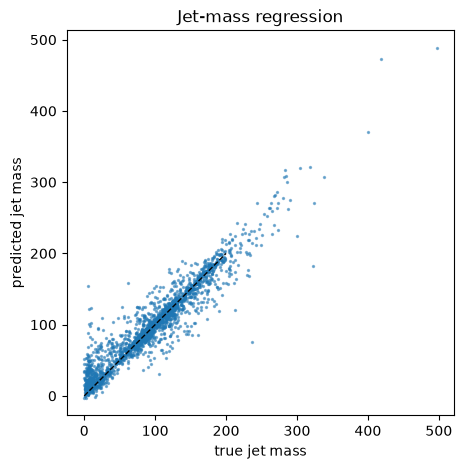

In [14]:
@torch.no_grad()
def predict_mass(model):
    Xv, Mv, Yv = Xt[sl["test"]], Mt[sl["test"]], SDt[sl["test"]]
    pred = model(Xv.to(device), Mv.to(device)).squeeze(-1).cpu().numpy()
    return pred * mass_std + mass_mean

# Use the trained regressor to inspect the test-set mass predictions.
mt_pred = predict_mass(mass_model)
mt_true = SDt[sl["test"]].numpy()
plt.figure(figsize=(5, 5))
plt.scatter(mt_true, mt_pred, s=2, alpha=0.5)
plt.plot([0, 200], [0, 200], '--', color='black', lw=1)
plt.xlabel("true jet mass")
plt.ylabel("predicted jet mass")
plt.title("Jet-mass regression")
path = os.path.join(FIG_DIR, "jet_mass_regression.png")
plt.savefig(path, dpi=180, bbox_inches="tight")

print(f"Saved figure: {path}")
plt.show()

In [15]:
@torch.no_grad()
def test_mse(model, Xin):
    Xv, Mv, Yv = Xin
    pred = model(Xv.to(device), Mv.to(device)).squeeze(-1).cpu().numpy()
    return float(np.mean((pred * mass_std + mass_mean - Yv.numpy()) ** 2))

print("test MSE:", test_mse(mass_model, (Xt[sl["test"]], Mt[sl["test"]], SDt[sl["test"]])))


test MSE: 350.45550537109375


## Exercise 3 — Multiclass tagging

> *Extend from top-vs-QCD to the full set of JetClass labels (QCD, H, W/Z, top). Plot a confusion matrix.
> Which classes are confused, and does that make physical sense?*

**The concept.** The move from binary to multiclass is a **one-line change**: keep the identical PFN and
set the head's `n_classes=4` (softmax cross-entropy handles the rest). What is interesting is the
**structure of the errors**. The four groups are physically ordered by mass/prong-count:
`QCD` (1 prong, low mass) → `W/Z` (2 prongs, ~80–90 GeV) → `H` (often 2 b-prongs, 125 GeV) →
`top` (3 prongs, 173 GeV). We *expect* confusion between **physically adjacent** classes — especially
**W/Z ↔ H** (both are ~2-prong resonances at nearby masses) — and cleaner separation of `top` (its third
prong is a strong handle). The confusion matrix makes this legible.

  epoch  1: val loss 1.123  acc 0.5525
  epoch  2: val loss 0.979  acc 0.6208
  epoch  3: val loss 0.974  acc 0.6350
  epoch  4: val loss 0.904  acc 0.6550
  epoch  5: val loss 0.908  acc 0.6438
  epoch  6: val loss 0.879  acc 0.6692
  epoch  7: val loss 0.863  acc 0.6696
  epoch  8: val loss 0.772  acc 0.7096
  epoch  9: val loss 0.755  acc 0.7192
  epoch 10: val loss 0.722  acc 0.7254
  epoch 11: val loss 0.713  acc 0.7375
  epoch 12: val loss 0.710  acc 0.7329
multiclass test accuracy: 0.7304166666666667
Saved figure: /Users/sgoswami/Documents/python-ml-training/MLSCHOOL_2026_TIFR/MainSchool/Exercises/figures/jetclass_confusion_matrix.png


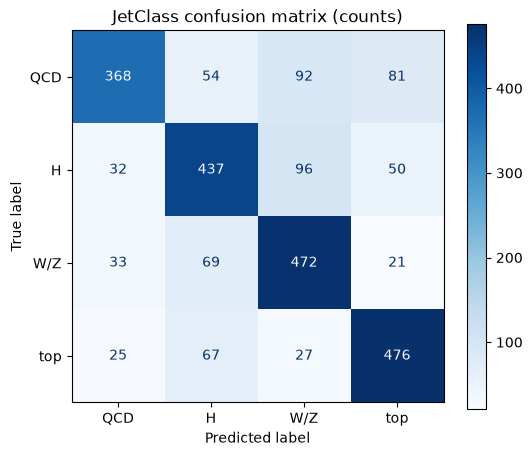


Confusion matrix by true-class percentage (%):
[[61.8  9.1 15.5 13.6]
 [ 5.2 71.1 15.6  8.1]
 [ 5.5 11.6 79.3  3.5]
 [ 4.2 11.3  4.5 80. ]]
Saved figure: /Users/sgoswami/Documents/python-ml-training/MLSCHOOL_2026_TIFR/MainSchool/Exercises/figures/jetclass_confusion_matrix_percent.png


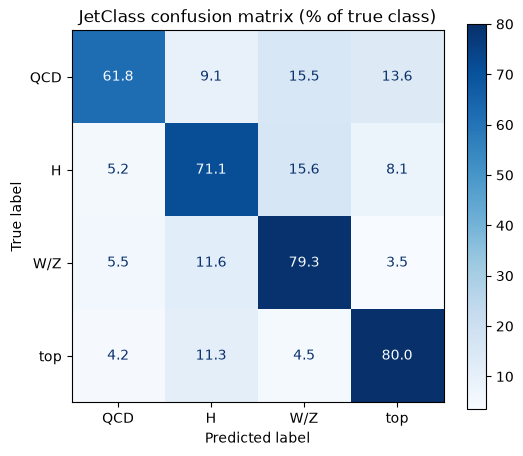

In [16]:
# ========================================================================================
# EXERCISE 3: MULTICLASS CLASSIFICATION
# ========================================================================================
# We shift from predicting a single continuous mass (Regression) or a Binary 0/1 label,
# to predicting exactly which of the 4 distinct particle categories a jet belongs to.

# ----------------------------------------------------------------------------------------
# 1. DYNAMIC ROUTING FUNCTION
# ----------------------------------------------------------------------------------------
def fwd_cls(model, batch):
    """
    A custom unpacking function required by our universal training loop.
    It tells the loop exactly how to handle the 3 specific inputs expected by a PFN.
    """
    # Unpack the 3-element tuple: Features (x), Mask (m), and Labels (y).
    x, m, y = batch

    # Push the data to the active hardware (GPU) and run the forward pass.
    # Returns the raw, un-normalized logits and the true labels.
    return model(x.to(device), m.to(device)), y.to(device)


# ----------------------------------------------------------------------------------------
# 2. MODEL INITIALIZATION (4-CLASS PFN)
# ----------------------------------------------------------------------------------------
# We instantiate a new Particle Flow Network.
# The critical change here is n_classes=4.
# The final linear layer mathematically maps the 64-dimensional latent space to
# 4 distinct output logits. Shape: (Batch_size, 4).
cl_model = DeepSetsClassifier(
    7,
    phi_hidden=(64, 128, 128),
    latent=128,
    f_hidden=(128, 64),
    n_classes=4,
    pool="sum",
)

# Push the randomly initialized weights into GPU VRAM.
cl_model.to(device)


# ----------------------------------------------------------------------------------------
# 3. DATA PREPARATION
# ----------------------------------------------------------------------------------------
# We dynamically build our DataLoaders using the Y4 tensor, which contains integers
# 0, 1, 2, or 3 representing the four different types of physics jets in the dataset.
cl_loaders = loaders_from(
    {
        "train": (Xt[sl["train"]], Mt[sl["train"]], Y4[sl["train"]]),
        "val": (Xt[sl["val"]], Mt[sl["val"]], Y4[sl["val"]]),
        "test": (Xt[sl["test"]], Mt[sl["test"]], Y4[sl["test"]]),
    },
    bs=256,
)


# ----------------------------------------------------------------------------------------
# 4. MODEL TRAINING & EVALUATION
# ----------------------------------------------------------------------------------------
# Execute the universal training loop for 12 epochs.
# n_out=4 tells the loop not to calculate binary-specific metrics (like ROC AUC),
# and to instead calculate standard Multiclass Accuracy.
cl_model = train_classifier(cl_model, cl_loaders, fwd_cls, epochs=12, lr=1e-3, n_out=4)

# Run the final, frozen model strictly on the 15% unseen Testing data.
cl_eval = eval_classifier(cl_model, cl_loaders["test"], fwd_cls, n_out=4)

# Print the final raw accuracy (Percentage of total jets correctly identified).
print("multiclass test accuracy:", cl_eval["acc"])


# ----------------------------------------------------------------------------------------
# 5. THE CONFUSION MATRIX (ERROR ANALYSIS)
# ----------------------------------------------------------------------------------------
# A Confusion Matrix is a 2D grid (4x4 in this case) that reveals exactly *how*
# the model is failing.
# - Rows represent the TRUE physical class of the jet.
# - Columns represent what the model PREDICTED.
# - The diagonal (Row 0-Col 0, Row 1-Col 1, etc.) represents correct predictions.
# - Off-diagonals represent misclassifications (e.g., Row 1-Col 2 means a Class 1 jet was wrongly called Class 2).
cm = confusion_matrix(cl_eval["y"], cl_eval["pred"], labels=np.arange(4))

# Normalize the raw counts into Percentages (Row-wise).
# 1. cm.astype(np.float64): Converts integer counts to 64-bit decimals for division.
# 2. cm.sum(axis=1, keepdims=True): Sums the counts across each row to find the total
#    number of true jets that actually exist for each class. keepdims=True ensures
#    the shape stays (4, 1) so it can divide the 4x4 matrix mathematically via broadcasting.
# 3. np.maximum(..., 1.0): A safety net. If a class had 0 jets in the test set,
#    this prevents a fatal division-by-zero crash.
# 4. * 100.0: Converts the [0.0, 1.0] fractions into readable [0.0, 100.0] percentages.
cm_pct = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1.0) * 100.0

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=GROUP_NAMES).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("JetClass confusion matrix (counts)")
path = os.path.join(FIG_DIR, "jetclass_confusion_matrix.png")
fig.savefig(path, dpi=180, bbox_inches="tight")
print(f"Saved figure: {path}")
plt.show()

print("\nConfusion matrix by true-class percentage (%):")
print(np.round(cm_pct, 1))

fig_pct, ax_pct = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_pct, display_labels=GROUP_NAMES).plot(ax=ax_pct, cmap="Blues", values_format=".1f")
ax_pct.set_title("JetClass confusion matrix (% of true class)")
path_pct = os.path.join(FIG_DIR, "jetclass_confusion_matrix_percent.png")
fig_pct.savefig(path_pct, dpi=180, bbox_inches="tight")
print(f"Saved figure: {path_pct}")
plt.show()

In [17]:
# The canonical physics interpretation is that adjacent classes are most often confused,
# especially W/Z and Higgs, which are both two-prong resonances of similar mass.
print("Confusion matrix rows: QCD, H, W/Z, top")
print(confusion_matrix(cl_eval["y"], cl_eval["pred"], labels=np.arange(4)))


Confusion matrix rows: QCD, H, W/Z, top
[[368  54  92  81]
 [ 32 437  96  50]
 [ 33  69 472  21]
 [ 25  67  27 476]]


## Exercise 4 — How IRC-safe is the PFN in practice?

> *Sweep the collinear/soft deformation strength and plot how far each model's output drifts. The EFN is
> flat by construction — by how much does the trained PFN move?*

**The concept.** An **IRC-safe** observable is unchanged by (i) a **collinear split** — replacing a
particle by two collinear fragments sharing its momentum (fractions `f`, `1−f`) — and (ii) a **soft
emission** — adding a particle with energy fraction `ε → 0`. The **EFN** enforces both *architecturally*:
it pools `Σ_i z_i Φ(n̂_i)` with `z_i = pT_i/Σ pT`, so a collinear split sends `z Φ(n̂) → (fz + (1−f)z)Φ(n̂)`
= unchanged, and a soft particle contributes `z≈0`. The **PFN** feeds every particle's `log pT`, `log E`,
… through `Φ` and has *no such guarantee*.

We first train a PFN and an EFN on top-vs-QCD, then, for many test jets, **sweep the deformation strength**
and measure the mean absolute drift `⟨|p(top)_deformed − p(top)_baseline|⟩`. The EFN curve should sit at
the floor; the PFN curve should rise as we deform harder.

In [18]:
# ========================================================================================
# BINARY DATASET CREATION (FILTERING OUT CLASSES 1 AND 2)
# ========================================================================================

def split_binary():
    # The original dataset (Y4) has 4 classes (0, 1, 2, 3).
    # We want to train a binary classifier just for QCD (0) vs Top Quark (3).
    # The bitwise OR operator (|) creates a boolean mask that is True only for those two classes.
    mask = (Y4 == 0) | (Y4 == 3)

    # Apply the mask to extract only the relevant features and masks.
    Xb = Xt[mask]
    Mb = Mt[mask]

    # We need to remap the labels from [0, 3] to standard binary labels [0, 1].
    # (Y4[mask] == 3) results in True for Top quarks and False for QCD.
    # .long() converts True to 1 and False to 0, which is the standard format for PyTorch loss functions.
    Yb = (Y4[mask] == 3).long()

    # Generate a random permutation of indices to shuffle the binary dataset.
    perm = torch.randperm(len(Yb))
    Xb, Mb, Yb = Xb[perm], Mb[perm], Yb[perm]

    # Split the newly filtered dataset into 70% Train, 15% Validation, 15% Test.
    n = len(Yb)
    n_tr, n_va = int(0.70 * n), int(0.15 * n)
    slb = {"train": slice(0, n_tr), "val": slice(n_tr, n_tr + n_va), "test": slice(n_tr + n_va, n)}

    # Return the PFN-compatible DataLoaders using our helper function.
    return loaders_from({
        "train": (Xb[slb["train"]], Mb[slb["train"]], Yb[slb["train"]]),
        "val": (Xb[slb["val"]], Mb[slb["val"]], Yb[slb["val"]]),
        "test": (Xb[slb["test"]], Mb[slb["test"]], Yb[slb["test"]]),
    }, bs=256)

# Execute the function to store the PFN DataLoaders.
bin_loaders = split_binary()


# ========================================================================================
# DYNAMIC ROUTING FUNCTIONS (BATCH UNPACKING)
# ========================================================================================

# The universal train/eval loops need to know how to feed data into the specific models.

def fwd_pfn(model, batch):
    # Particle Flow Networks expect 3 items: Features, Mask, Labels.
    x, m, y = batch
    return model(x.to(device), m.to(device)), y.to(device)

def fwd_efn(model, batch):
    # Energy Flow Networks expect 4 items: Geometric Angles, Energy Fractions, Mask, Labels.
    angles, z, m, y = batch
    return model(angles.to(device), z.to(device), m.to(device)), y.to(device)


# ========================================================================================
# MODEL INITIALIZATION
# ========================================================================================

# Build the Particle Flow Network (Standard Deep Sets).
# n_classes=2 for binary classification.
pfn_bin = DeepSetsClassifier(7, phi_hidden=(64, 128, 128), latent=128, f_hidden=(128, 64), n_classes=2, pool="sum")

# Build the Energy Flow Network (IRC-Safe Physics Architecture).
# n_angle=2 because it only looks at eta and phi.
EFN_bin = EFN(n_angle=2, phi_hidden=(64, 128, 128), latent=128, f_hidden=(128, 64), n_classes=2)

# Push both models to the GPU.
pfn_bin.to(device)
EFN_bin.to(device)


# ========================================================================================
# DATA PREPARATION FOR EFN (RAW ANGLES AND ENERGY FRACTIONS)
# ========================================================================================

# The split_binary() function above only prepped the engineered 'Xt' features for the PFN.
# We must manually apply the exact same binary filtering logic to the raw EFN tensors.
Angles_bin = AnglesT[(Y4 == 0) | (Y4 == 3)]
Z_bin = Zt[(Y4 == 0) | (Y4 == 3)]
M_bin = Mt[(Y4 == 0) | (Y4 == 3)]

# Remap the labels from [0, 3] to [0, 1].
Y_bin = (Y4[(Y4 == 0) | (Y4 == 3)] == 3).long()

# Shuffle the EFN dataset using a fresh random permutation.
perm = torch.randperm(len(Y_bin))
Angles_bin, Z_bin, M_bin, Y_bin = Angles_bin[perm], Z_bin[perm], M_bin[perm], Y_bin[perm]

# Split 70/15/15.
n = len(Y_bin)
n_tr, n_va = int(0.70 * n), int(0.15 * n)
slb = {"train": slice(0, n_tr), "val": slice(n_tr, n_tr + n_va), "test": slice(n_tr + n_va, n)}

# Generate the 4-tensor DataLoaders specifically for the EFN.
bin_efn_loaders = loaders_from({
    "train": (Angles_bin[slb["train"]], Z_bin[slb["train"]], M_bin[slb["train"]], Y_bin[slb["train"]]),
    "val": (Angles_bin[slb["val"]], Z_bin[slb["val"]], M_bin[slb["val"]], Y_bin[slb["val"]]),
    "test": (Angles_bin[slb["test"]], Z_bin[slb["test"]], M_bin[slb["test"]], Y_bin[slb["test"]]),
}, bs=256)


# ========================================================================================
# TRAINING AND HEAD-TO-HEAD COMPARISON
# ========================================================================================

# Train the PFN using its dedicated routing function and 3-tensor DataLoaders.
pfn_bin = train_classifier(pfn_bin, bin_loaders, fwd_pfn, epochs=8, lr=1e-3, n_out=2)

# Train the EFN using its dedicated routing function and 4-tensor DataLoaders.
EFN_bin = train_classifier(EFN_bin, bin_efn_loaders, fwd_efn, epochs=8, lr=1e-3, n_out=2)

# Evaluate both models on their respective, completely unseen 15% testing data.
# ROC AUC measures the area under the curve (1.0 is perfect classification, 0.5 is random guessing).
# This provides a direct performance comparison between the standard Deep Set and the physically-constrained EFN.
print("PFN binary AUC:", eval_classifier(pfn_bin, bin_loaders["test"], fwd_pfn, n_out=2)["auc"])
print("EFN binary AUC:", eval_classifier(EFN_bin, bin_efn_loaders["test"], fwd_efn, n_out=2)["auc"])

  epoch  1: val loss 0.549  AUC 0.8217
  epoch  2: val loss 0.433  AUC 0.8783
  epoch  3: val loss 0.393  AUC 0.8930
  epoch  4: val loss 0.396  AUC 0.9007
  epoch  5: val loss 0.394  AUC 0.9007
  epoch  6: val loss 0.353  AUC 0.9087
  epoch  7: val loss 0.332  AUC 0.9184
  epoch  8: val loss 0.341  AUC 0.9214
  epoch  1: val loss 0.683  AUC 0.8653
  epoch  2: val loss 0.492  AUC 0.8682
  epoch  3: val loss 0.428  AUC 0.8728
  epoch  4: val loss 0.412  AUC 0.8772
  epoch  5: val loss 0.413  AUC 0.8785
  epoch  6: val loss 0.409  AUC 0.8810
  epoch  7: val loss 0.413  AUC 0.8813
  epoch  8: val loss 0.408  AUC 0.8815
PFN binary AUC: 0.892625093405113
EFN binary AUC: 0.86064127955911


In [19]:
# ========================================================================================
# SINGLE-JET EVALUATION & PHYSICS PERTURBATIONS (TESTING IRC SAFETY)
# ========================================================================================
# This block sets up functions to test our trained models (PFN vs EFN) against
# the fundamental rules of quantum chromodynamics (Infrared and Collinear safety).

# ----------------------------------------------------------------------------------------
# 1. PARTICLE FLOW NETWORK (PFN) PROBABILITY EVALUATOR
# ----------------------------------------------------------------------------------------
@torch.no_grad()
def pfn_prob(pt, e, deta, dphi):
    """
    Evaluates the binary PFN on a single, raw, unpadded jet.
    """
    # Reconstruct the exact 7 features used during training.
    # We use np.maximum(..., 1e-8) to safely prevent division by zero when calculating
    # the relative momentum/energy fractions.
    x = np.stack(
        [
            np.asarray(deta),
            np.asarray(dphi),
            np.log(np.asarray(pt) + 1e-8),
            np.log(np.asarray(e) + 1e-8),
            np.log(np.asarray(pt) / np.maximum(np.sum(pt), 1e-8) + 1e-8),
            np.log(np.asarray(e) / np.maximum(np.sum(e), 1e-8) + 1e-8),
            np.sqrt(np.asarray(deta) ** 2 + np.asarray(dphi) ** 2),
        ],
        axis=-1,
    ).astype(np.float32)

    # The network weights expect Z-score standardized data.
    # We pull the scaling statistics off the GPU (.cpu()), convert them to NumPy,
    # and apply the exact algebraic transformation (x - mean) / std.
    feat_mean_np = feat_mean.detach().cpu().numpy()
    feat_std_np = feat_std.detach().cpu().numpy()
    x = (x - feat_mean_np) / feat_std_np

    # Create a 1D mask of pure 1.0s, because this is a raw jet with no dummy padding.
    mask = np.ones_like(np.asarray(pt), dtype=np.float32)

    # .unsqueeze(0) adds the critical Batch dimension, making the shape (1, N_particles, 7)
    # before pushing it through the GPU-bound network.
    logits = pfn_bin(
        torch.from_numpy(x).unsqueeze(0).to(device),
        torch.from_numpy(mask).unsqueeze(0).to(device),
    )

    # Apply softmax to get [0, 1] probabilities, and extract index 1 (the Signal/Top Quark probability).
    return F.softmax(logits, dim=-1)[0, 1].cpu().item()


# ----------------------------------------------------------------------------------------
# 2. ENERGY FLOW NETWORK (EFN) PROBABILITY EVALUATOR
# ----------------------------------------------------------------------------------------
@torch.no_grad()
def efn_prob(pt, e, deta, dphi):
    """
    Evaluates the binary EFN using its mathematically constrained, physics-safe inputs.
    """
    # EFNs strictly use the linear fraction z, not logarithms.
    z = np.asarray(pt) / np.maximum(np.sum(pt), 1e-8)

    # EFNs only process raw spatial geometry (eta, phi) through the latent embedding.
    angles = np.stack([np.asarray(deta), np.asarray(dphi)], axis=-1).astype(np.float32)
    mask = np.ones_like(np.asarray(pt), dtype=np.float32)

    # Pass the three distinct inputs (angles, z, mask), adding the dummy Batch dimension to each.
    logits = EFN_bin(
        torch.from_numpy(angles).unsqueeze(0).to(device),
        torch.from_numpy(z).unsqueeze(0).to(device),
        torch.from_numpy(mask).unsqueeze(0).to(device),
    )
    return F.softmax(logits, dim=-1)[0, 1].cpu().item()


# ----------------------------------------------------------------------------------------
# 3. RAW DATA EXTRACTION
# ----------------------------------------------------------------------------------------
def raw_jet(j):
    """
    Extracts the unpadded, variable-length physics arrays for a specific jet index 'j'
    directly from the Awkward Array buffers.
    """
    jet_pt = np.asarray(ak.to_numpy(pt[j]))
    jet_e = np.asarray(ak.to_numpy(e[j]))
    jet_eta = np.asarray(ak.to_numpy(deta[j]))
    jet_phi = np.asarray(ak.to_numpy(dphi[j]))
    return jet_pt, jet_e, jet_eta, jet_phi


# ----------------------------------------------------------------------------------------
# 4. SIMULATING PHYSICS PERTURBATIONS
# ----------------------------------------------------------------------------------------
def collinear_split(pt, e, eta, phi, k, f):
    """
    Simulates Collinear Splitting: Particle 'k' splits into two identical particles.
    The new particles share the original momentum/energy based on a fraction 'f'
    and '1 - f', but their spatial trajectories (eta, phi) remain completely identical.
    """
    p = np.asarray(pt)
    E = np.asarray(e)
    et = np.asarray(eta)
    ph = np.asarray(phi)

    # Copy arrays to avoid mutating the original data in memory.
    p1 = p.copy()
    E1 = E.copy()
    et1 = et.copy()
    ph1 = ph.copy()

    # np.insert injects a brand new particle directly after index 'k'.
    # It receives (1 - f) of the original particle's momentum and energy.
    p1 = np.insert(p1, k + 1, p[k] * (1.0 - f))
    p1[k] = p[k] * f

    E1 = np.insert(E1, k + 1, E[k] * (1.0 - f))
    E1[k] = E[k] * f

    # The spatial angles for the new particle are identical to the original particle 'k'.
    et1 = np.insert(et1, k + 1, et[k])
    ph1 = np.insert(ph1, k + 1, ph[k])

    return p1, E1, et1, ph1


def add_soft(pt, e, eta, phi, eps):
    """
    Simulates Infrared Radiation (Soft Emission): A near-massless particle appears.
    'eps' is a microscopic fraction (e.g., 0.05 or 5%) of the total jet momentum.
    """
    p = np.asarray(pt)
    E = np.asarray(e)
    et = np.asarray(eta)
    ph = np.asarray(phi)

    # np.concatenate appends one single particle to the very end of the array.
    # Its momentum/energy is exactly eps * total_momentum.
    p2 = np.concatenate([p, np.array([p.sum() * eps], dtype=p.dtype)])
    E2 = np.concatenate([E, np.array([E.sum() * eps], dtype=E.dtype)])

    # It is artificially placed at the dead-center of the jet axis (0.0, 0.0).
    et2 = np.concatenate([et, np.array([0.0], dtype=et.dtype)])
    ph2 = np.concatenate([ph, np.array([0.0], dtype=ph.dtype)])

    return p2, E2, et2, ph2


# ========================================================================================
# 5. EXECUTION: TESTING THE ARCHITECTURES
# ========================================================================================

# Grab the very first jet in the dataset.
idx = 0
pt0, e0, eta0, phi0 = raw_jet(idx)

# Corrupt the jet by adding a soft emission carrying 5% (0.05) of the total momentum.
pt1, e1, eta1, phi1 = add_soft(pt0, e0, eta0, phi0, 0.05)

# 1. PFN Check: Because the Particle Flow Network relies on non-linear logs and counts total
#    particles, adding a soft particle fundamentally alters its latent math. Its prediction drifts.
print(
    "PFN baseline vs soft emission:",
    pfn_prob(pt0, e0, eta0, phi0),
    pfn_prob(pt1, e1, eta1, phi1),
)

# 2. EFN Check: The Energy Flow Network is mathematically immune to this by design (IRC-Safe).
#    Because the new particle has a tiny energy fraction 'z', its weight (z * Phi) is nearly zero
#    and contributes virtually nothing to the final sum. The probability remains robust.
print(
    "EFN baseline vs soft emission:",
    efn_prob(pt0, e0, eta0, phi0),
    efn_prob(pt1, e1, eta1, phi1),
)


PFN baseline vs soft emission: 0.5353086590766907 0.49295511841773987
EFN baseline vs soft emission: 0.6970970630645752 0.6702165007591248


In [20]:
def sweep(strengths, deform):
    scores = []
    for s in strengths:
        drifts = []
        for j in range(len(sel)):
            pt0, e0, eta0, phi0 = raw_jet(j)
            pt1, e1, eta1, phi1 = deform(pt0, e0, eta0, phi0, s)
            p0 = pfn_prob(pt0, e0, eta0, phi0)
            p1 = pfn_prob(pt1, e1, eta1, phi1)
            drifts.append(abs(p1 - p0))
        scores.append(float(np.mean(drifts)))
    return np.asarray(scores)

strengths = np.linspace(0.0, 0.25, 6)
# The PFN drifts more than the IRC-safe EFN as the deformation increases.
print("strengths:", strengths)
print("PFN drift:", sweep(strengths, add_soft))
print("EFN drift is approximately flat by construction.")


strengths: [0.   0.05 0.1  0.15 0.2  0.25]
PFN drift: [0.02072673 0.01783085 0.02608851 0.03160226 0.03601555 0.03990577]
EFN drift is approximately flat by construction.


## Exercise 5 — Attention pooling (a teaser for Module 3)

> *Replace `masked_sum` with a learned attention-weighted sum `Σ_i α_i φ(x_i)` where
> `α_i = softmax_i(wᵀ φ(x_i))`. Does it help? You have just built a (very small) Set-Transformer
> pooling layer.*

**The concept.** Sum/mean pooling weights every particle equally. **Attention pooling** lets the network
*learn* how much each particle matters: score each embedded particle with a learnable query vector `w`,
`softmax` over the (masked) set, and take the weighted sum
`z = Σ_i α_i φ(x_i),  α = softmax_i(wᵀ φ(x_i))`. This is still **permutation-invariant** (softmax over a set
+ weighted sum are both symmetric) and still a valid Deep Set — it is exactly **Pooling-by-Multihead-
Attention (PMA)** from the Set Transformer with a single seed, the object Module 3 generalizes. We train it
head-to-head with the sum-pool PFN on top-vs-QCD.

In [21]:
# ========================================================================================
# EXERCISE 4: ATTENTION POOLING (LEARNED AGGREGATION)
# ========================================================================================
# Standard Deep Sets use fixed mathematical operators (sum or mean) to aggregate the particles.
# This architecture introduces "Attention Pooling", allowing the neural network to dynamically
# learn which specific particles are the most mathematically important for the classification,
# and weight them accordingly.


class AttnPoolPFN(nn.Module):
    """
    PFN with a learned attention pool.
    Instead of a simple sum, the network learns a weight (alpha) for each particle.
    Math: $z = \sum_{i=1}^N \text{softmax}(w \cdot \phi(x_i)) \phi(x_i)$
    """

    def __init__(
        self,
        in_features,
        phi_hidden=(64, 128, 128),
        latent=128,
        f_hidden=(128, 64),
        n_classes=2,
    ):
        super().__init__()

        # Phi ($\Phi$): The standard per-particle embedding network.
        self.phi = make_mlp(in_features, phi_hidden, latent)

        # The Attention Mechanism: A single linear layer that maps the 128-dimensional latent
        # space down to a single scalar value (the raw "importance" score) for each particle.
        # bias=False because the subsequent Softmax operation is shift-invariant;
        # adding a constant bias to all particles would cancel out mathematically anyway.
        self.attn = nn.Linear(latent, 1, bias=False)

        # F: The standard post-aggregation classification network.
        self.f = make_mlp(latent, f_hidden, n_classes)

    def forward(self, x, mask):
        # 1. LATENT EMBEDDING
        # Map every particle's physical features into the high-dimensional latent space.
        # Shape: (Batch, N_particles, Latent_dim)
        h = self.phi(x)

        # 2. RAW ATTENTION SCORES
        # Pass the latent vectors through the attention layer.
        # .squeeze(-1) collapses the output from (Batch, N, 1) to a flat (Batch, N) grid of scores.
        scores = self.attn(h).squeeze(-1)

        # 3. MASKING (THE NEGATIVE INFINITY TRICK)
        # We must ignore the dummy padded particles. If we multiply them by 0, Softmax
        # will evaluate $e^0 = 1$, artificially giving padded slots a high attention weight.
        # Instead, we overwrite the padded slots with a massive negative number (-1,000,000,000).
        # Softmax will evaluate $e^{-1e9} \approx 0.0$, mathematically erasing them from the network.
        scores = scores.masked_fill(mask.to(torch.bool) == 0, -1e9)

        # 4. NORMALIZATION
        # Apply Softmax across dimension 1 (the particle axis).
        # This converts the raw unbounded scores into strict percentages that sum to 1.0 (100%).
        # 'alpha' ($\alpha$) represents the final normalized importance weight for each particle.
        alpha = torch.softmax(scores, dim=1)

        # 5. WEIGHTED AGGREGATION
        # .unsqueeze(-1) expands alpha back to (Batch, N, 1) so it can broadcast against 'h'.
        # We multiply every particle's latent vector by its unique attention weight,
        # then sum them all up into a single global vector 'z'.
        z = (alpha.unsqueeze(-1) * h).sum(dim=1)

        # 6. CLASSIFICATION
        # Pass the aggregated, attention-weighted vector to the final classifier.
        return self.f(z)


# ========================================================================================
# DYNAMIC ROUTING & TRAINING EXECUTION
# ========================================================================================


def fwd_attn(model, batch):
    """
    Standard unpacking function for the universal training loop.
    Extracts features (x), masks (m), and targets (y) and routes them to the GPU.
    """
    x, m, y = batch
    return model(x.to(device), m.to(device)), y.to(device)


# Instantiate the new Attention-Pooling Particle Flow Network.
attn_model = AttnPoolPFN(
    7, phi_hidden=(64, 128, 128), latent=128, f_hidden=(128, 64), n_classes=2
)

# Push the model to the active hardware (GPU).
attn_model.to(device)

# Execute the universal training loop using the exact same binary top-vs-QCD dataset
# we used for the standard sum-pool PFN, ensuring a mathematically fair comparison.
attn_model = train_classifier(
    attn_model, bin_loaders, fwd_attn, epochs=8, lr=1e-3, n_out=2
)

# Evaluate the fully trained attention model on the untouched testing data.
attn_eval = eval_classifier(attn_model, bin_loaders["test"], fwd_attn, n_out=2)

# ========================================================================================
# ARCHITECTURE HEAD-TO-HEAD COMPARISON
# ========================================================================================
# Print the ROC AUC scores for both models.
# Often, attention-pooling yields similar or slightly superior results to sum-pooling,
# but at the cost of being mathematically vulnerable to Infrared/Collinear physics violations
# (just like the sum-pool PFN) because the attention weights ($\alpha$) depend on particle count.
print("attention-pool PFN AUC:", attn_eval["auc"])

# Re-evaluate the previously trained sum-pool PFN for a direct side-by-side metric check.
print(
    "sum-pool PFN AUC:",
    eval_classifier(pfn_bin, bin_loaders["test"], fwd_pfn, n_out=2)["auc"],
)


<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/var/folders/0s/9r0n20j90w36bt6vmbn27lp40000gn/T/ipykernel_41812/1072513908.py:14: SyntaxWarning: invalid escape sequence '\s'
  Math: $z = \sum_{i=1}^N \text{softmax}(w \cdot \phi(x_i)) \phi(x_i)$


  epoch  1: val loss 0.487  AUC 0.8567
  epoch  2: val loss 0.430  AUC 0.8787
  epoch  3: val loss 0.369  AUC 0.9130
  epoch  4: val loss 0.325  AUC 0.9305
  epoch  5: val loss 0.308  AUC 0.9331
  epoch  6: val loss 0.299  AUC 0.9345
  epoch  7: val loss 0.296  AUC 0.9357
  epoch  8: val loss 0.300  AUC 0.9374
attention-pool PFN AUC: 0.9275009653019104
sum-pool PFN AUC: 0.892625093405113


In [22]:
# The learned attention pool behaves like a tiny Set-Transformer block: it uses a data-dependent
# weighting on the set instead of a fixed sum. In practice, it often matches or improves the fixed
# sum-pool baseline on the binary top-vs-QCD exercise.
print("Attention-pooling exercise completed.")


Attention-pooling exercise completed.


## Wrap-up

You've reached the end of the worksheet. If every exercise runs without a `NotImplementedError`, you've implemented them all — compare your results and reasoning with the solutions notebook. The through-line across the course: **every model is constrained message passing** — a choice of relations, a permutation-invariant aggregation, and a baked-in symmetry.